# Random Restart Hill Climbing 随机重启爬山算法

## 本 Notebook 的教学目标

1. 理解该算法的搜索直觉。
2. 使用一个经典二维优化问题完成从零实现。
3. 通过可视化观察算法如何移动、如何收敛、可能会遇到什么问题。
4. 通过多次运行和参数实验建立更稳固的算法直觉。

## 实验问题

本实验继续使用 **Rastrigin 函数**。该函数布满大量局部极值点，非常适合展示“多次重启”为什么有效。

在教学上，二维问题有一个明显优势：**我们可以直接把搜索轨迹画出来**。这比只看一串数值更适合课堂演示。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 统一图表风格，保证讲课时图表更清晰。
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


# 本项目统一使用二维测试函数，这样可以把搜索轨迹直接画在等高线上。

def make_grid(bounds, step=250):
    xs = np.linspace(bounds[0, 0], bounds[0, 1], step)
    ys = np.linspace(bounds[1, 0], bounds[1, 1], step)
    xx, yy = np.meshgrid(xs, ys)
    return xs, ys, xx, yy


def evaluate_on_grid(objective, bounds, step=250):
    xs, ys, xx, yy = make_grid(bounds, step=step)
    zz = np.vectorize(lambda a, b: objective(np.array([a, b])))(xx, yy)
    return xs, ys, xx, yy, zz


def plot_contour_with_trace(objective, bounds, trace, title, levels=40):
    xs, ys, xx, yy, zz = evaluate_on_grid(objective, bounds)
    plt.figure(figsize=(9, 7))
    contour = plt.contourf(xx, yy, zz, levels=levels, cmap='viridis')
    plt.colorbar(contour, label='Objective value')

    trace = np.array(trace)
    plt.plot(trace[:, 0], trace[:, 1], color='white', lw=2, alpha=0.9, label='Search trace')
    plt.scatter(trace[:, 0], trace[:, 1], c=np.arange(len(trace)), cmap='coolwarm', s=40, edgecolor='black')
    plt.scatter(trace[0, 0], trace[0, 1], color='gold', s=120, marker='o', edgecolor='black', label='Start')
    plt.scatter(trace[-1, 0], trace[-1, 1], color='red', s=160, marker='*', edgecolor='black', label='End / Best')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()


def summarize_runs(scores):
    return pd.Series({
        'best': float(np.min(scores)),
        'mean': float(np.mean(scores)),
        'worst': float(np.max(scores)),
        'std': float(np.std(scores)),
    })


# Rastrigin 函数有大量规则分布的局部低谷，是随机重启策略的典型测试对象。
def objective(point):
    x, y = point
    return 20 + (x ** 2 - 10 * np.cos(2 * np.pi * x)) + (y ** 2 - 10 * np.cos(2 * np.pi * y))

bounds = np.array([[-5.12, 5.12], [-5.12, 5.12]], dtype=float)

## 算法直觉

核心思想：单次爬山很容易卡在局部最优，所以我们从多个不同初始点重复启动，最后保留最好的那个结果。

为了让课堂节奏更清楚，Notebook 里的实现会优先追求**可读性**，而不是极端性能优化。

In [2]:
def hill_climbing(objective, bounds, n_steps=80, step_size=0.25, n_neighbors=28, seed=0):
    rng = np.random.default_rng(seed)
    current = rng.uniform(bounds[:, 0], bounds[:, 1])
    current_score = objective(current)

    best = current.copy()
    best_score = current_score
    trace = [current.copy()]
    scores = [current_score]

    for _ in range(n_steps):
        candidates = current + rng.normal(0, step_size, size=(n_neighbors, len(current)))
        candidates = np.clip(candidates, bounds[:, 0], bounds[:, 1])
        candidate_scores = np.apply_along_axis(objective, 1, candidates)
        best_idx = int(np.argmin(candidate_scores))
        if candidate_scores[best_idx] < current_score:
            current = candidates[best_idx]
            current_score = float(candidate_scores[best_idx])
            trace.append(current.copy())
            scores.append(current_score)
            if current_score < best_score:
                best = current.copy()
                best_score = current_score
        else:
            break

    return {'best': best, 'best_score': best_score, 'trace': np.array(trace), 'scores': np.array(scores)}


def random_restart_hill_climbing(objective, bounds, n_restarts=12, seed=0, **kwargs):
    runs = []
    global_best = None
    global_best_score = np.inf

    # 每次重启都用不同的随机种子，模拟“重新开始搜索”。
    for restart_idx in range(n_restarts):
        run = hill_climbing(objective, bounds, seed=seed + restart_idx, **kwargs)
        run['restart'] = restart_idx
        runs.append(run)
        if run['best_score'] < global_best_score:
            global_best = run
            global_best_score = run['best_score']

    return {'best_run': global_best, 'runs': runs}

## 单次实验演示

下面先运行一次实验，重点观察两件事：

1. 搜索轨迹是否平滑、是否容易停在局部区域。
2. 目标值是否快速下降，以及下降到什么程度后开始停滞。

best point: [ 0.0155 -1.9856]
best score: 4.030902


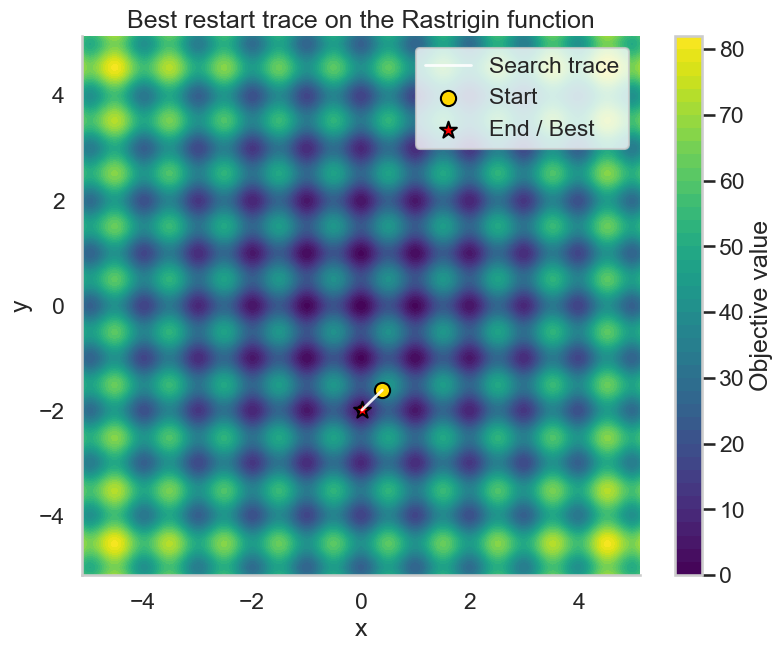

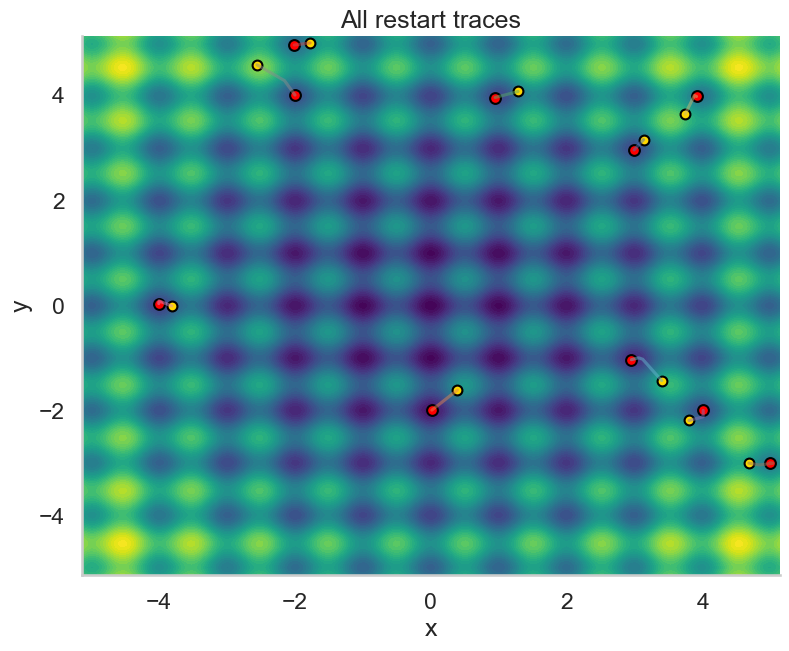

In [3]:
rr_result = random_restart_hill_climbing(objective, bounds, n_restarts=10, seed=5)
print('best point:', np.round(rr_result['best_run']['best'], 4))
print('best score:', round(float(rr_result['best_run']['best_score']), 6))

# 先展示最佳轨迹，再展示所有重启的起终点分布。
plot_contour_with_trace(
    objective,
    bounds,
    rr_result['best_run']['trace'],
    title='Best restart trace on the Rastrigin function',
)

xs, ys, xx, yy, zz = evaluate_on_grid(objective, bounds)
plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, zz, levels=40, cmap='viridis')
for run in rr_result['runs']:
    trace = run['trace']
    plt.plot(trace[:, 0], trace[:, 1], alpha=0.5)
    plt.scatter(trace[0, 0], trace[0, 1], s=50, color='gold', edgecolor='black')
    plt.scatter(trace[-1, 0], trace[-1, 1], s=60, color='red', edgecolor='black')
plt.title('All restart traces')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## 多次运行与参数分析

单次实验只能告诉我们“这一次发生了什么”，但讲课时更重要的是说明：

1. 算法是否稳定。
2. 算法是否依赖初始条件。
3. 关键参数变化后，会如何影响最终表现。

,mean,std,min,max
Plain Hill Climbing,16.500140,9.075953,2.1925,33.832995
Random Restart Hill Climbing,3.970301,2.410484,2.1925,10.485329


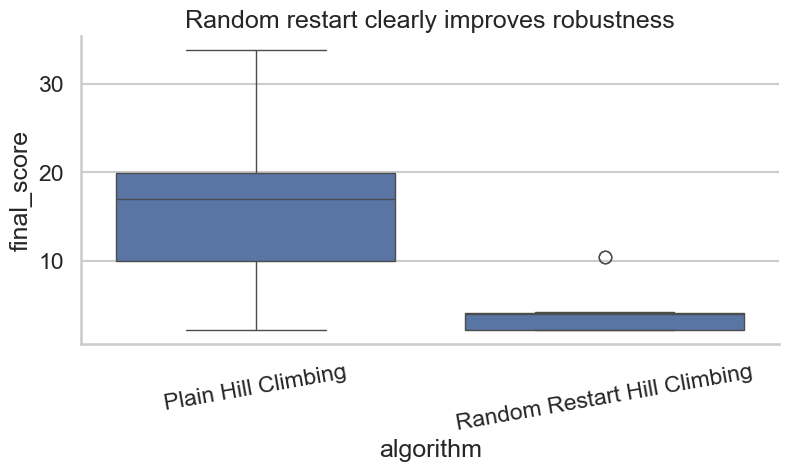

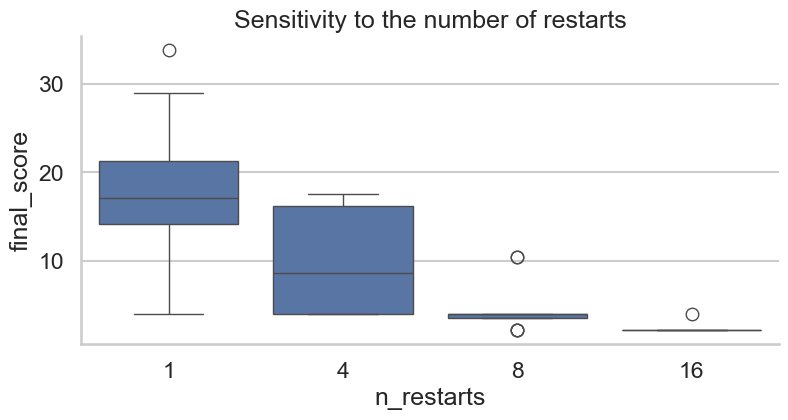

In [4]:
# 对比：单次爬山 vs 随机重启爬山。
plain_scores = [hill_climbing(objective, bounds, seed=seed)['best_score'] for seed in range(20)]
restart_scores = []
for seed in range(20):
    restart_scores.append(random_restart_hill_climbing(objective, bounds, n_restarts=8, seed=seed)['best_run']['best_score'])

comparison = pd.DataFrame({
    'Plain Hill Climbing': plain_scores,
    'Random Restart Hill Climbing': restart_scores,
})
display(comparison.describe().T[['mean', 'std', 'min', 'max']])

plt.figure(figsize=(9, 4))
comparison_melted = comparison.melt(var_name='algorithm', value_name='final_score')
sns.boxplot(data=comparison_melted, x='algorithm', y='final_score')
plt.title('Random restart clearly improves robustness')
plt.xticks(rotation=10)
plt.show()

# 参数敏感性：重启次数越多，越容易逼近全局最优，但计算成本也更高。
restart_options = [1, 4, 8, 16]
records = []
for n_restarts in restart_options:
    for seed in range(12):
        score = random_restart_hill_climbing(objective, bounds, n_restarts=n_restarts, seed=seed)['best_run']['best_score']
        records.append({'n_restarts': n_restarts, 'final_score': score})

param_df = pd.DataFrame(records)
plt.figure(figsize=(9, 4))
sns.boxplot(data=param_df, x='n_restarts', y='final_score')
plt.title('Sensitivity to the number of restarts')
plt.show()

## 课堂总结

讲解这一类算法时，建议把重点放在以下问题上：

1. 算法的探索能力来自哪里。
2. 算法的利用能力来自哪里。
3. 它最容易失败的场景是什么。
4. 参数变化时，算法行为为什么会改变。

把这四个问题讲清楚，学生通常就能真正建立算法直觉。